In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


## load dataset

In [2]:
df = pd.read_csv(
    "learntwin_student_interactions.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 10)


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [3]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df = df.sort_values(
    by=["student_id", "timestamp"]
).reset_index(drop=True)

print("Dataset sorted successfully!")

Dataset sorted successfully!


In [4]:
concept_encoder = LabelEncoder()

df["concept_encoded"] = (
    concept_encoder.fit_transform(
        df["concept"]
    )
)

print(
    "Number of concepts:",
    len(concept_encoder.classes_)
)

print(
    concept_encoder.classes_
)

Number of concepts: 20
['AGGREGATE FUNCTIONS' 'FOREIGN KEY' 'GROUP BY' 'HAVING' 'INDEXING'
 'INNER JOIN' 'JOINS' 'LEFT JOIN' 'NORMALIZATION' 'ORDER BY' 'PRIMARY KEY'
 'RIGHT JOIN' 'SELECT' 'STORED PROCEDURES' 'SUBQUERIES' 'TRANSACTIONS'
 'TRIGGERS' 'UNION' 'VIEWS' 'WHERE']


## Create sequences

In [5]:
SEQUENCE_LENGTH = 10

X_concept = []
X_numeric = []
y = []

target_attempts = []
target_students = []

for student_id, student_data in df.groupby(
    "student_id"
):

    student_data = student_data.sort_values(
        "attempt"
    ).reset_index(drop=True)

    for i in range(
        SEQUENCE_LENGTH,
        len(student_data)
    ):

        history_data = student_data.iloc[
            i - SEQUENCE_LENGTH:i
        ]

        current_data = student_data.iloc[i]

        # Concept history
        X_concept.append(
            history_data[
                "concept_encoded"
            ].values
        )

        # Numerical history
        X_numeric.append(
            history_data[
                [
                    "correct",
                    "difficulty",
                    "time_gap_days",
                    "days_since_practice"
                ]
            ].values
        )

        # Target
        y.append(
            current_data["correct"]
        )

        # Information about target
        target_attempts.append(
            current_data["attempt"]
        )

        target_students.append(
            current_data["student_id"]
        )

## Convert everything to NumPy

In [6]:
X_concept = np.array(
    X_concept,
    dtype=np.int32
)

X_numeric = np.array(
    X_numeric,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.float32
)

target_attempts = np.array(
    target_attempts,
    dtype=int
)

target_students = np.array(
    target_students
)

print("X_concept:", X_concept.shape)
print("X_numeric:", X_numeric.shape)
print("y:", y.shape)
print("target_attempts:", target_attempts.shape)

X_concept: (9000, 10)
X_numeric: (9000, 10, 4)
y: (9000,)
target_attempts: (9000,)


## Train/Test split

In [7]:
train_mask = target_attempts <= 80
test_mask = target_attempts > 80

# Training
X_concept_train = X_concept[train_mask]
X_numeric_train = X_numeric[train_mask]
y_train = y[train_mask]

# Testing
X_concept_test = X_concept[test_mask]
X_numeric_test = X_numeric[test_mask]
y_test = y[test_mask]

# Extra information
target_students_train = target_students[
    train_mask
]

target_students_test = target_students[
    test_mask
]

target_attempts_train = target_attempts[
    train_mask
]

target_attempts_test = target_attempts[
    test_mask
]

print(
    "Training concept shape:",
    X_concept_train.shape
)

print(
    "Training numeric shape:",
    X_numeric_train.shape
)

print(
    "Training target shape:",
    y_train.shape
)

print()

print(
    "Testing concept shape:",
    X_concept_test.shape
)

print(
    "Testing numeric shape:",
    X_numeric_test.shape
)

print(
    "Testing target shape:",
    y_test.shape
)

Training concept shape: (7000, 10)
Training numeric shape: (7000, 10, 4)
Training target shape: (7000,)

Testing concept shape: (2000, 10)
Testing numeric shape: (2000, 10, 4)
Testing target shape: (2000,)


## Scale numerical features

In [8]:
scaler = StandardScaler()

train_numeric_2d = X_numeric_train.reshape(
    -1,
    X_numeric_train.shape[-1]
)

test_numeric_2d = X_numeric_test.reshape(
    -1,
    X_numeric_test.shape[-1]
)

scaler.fit(
    train_numeric_2d
)

X_numeric_train = scaler.transform(
    train_numeric_2d
).reshape(
    X_numeric_train.shape
)

X_numeric_test = scaler.transform(
    test_numeric_2d
).reshape(
    X_numeric_test.shape
)

print(
    "Training numeric shape:",
    X_numeric_train.shape
)

print(
    "Testing numeric shape:",
    X_numeric_test.shape
)

Training numeric shape: (7000, 10, 4)
Testing numeric shape: (2000, 10, 4)


## Check class distribution

In [9]:
print("Training class distribution:")
print(
    pd.Series(y_train).value_counts()
)

print()

print("Testing class distribution:")
print(
    pd.Series(y_test).value_counts()
)

print()

print("Training percentages:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    * 100
)

Training class distribution:
0.0    4941
1.0    2059
Name: count, dtype: int64

Testing class distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Training percentages:
0.0    70.585714
1.0    29.414286
Name: proportion, dtype: float64


## Calculate class weights

In [10]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(
        classes,
        class_weights_array
    )
)

print("Class weights:")
print(class_weights)

Class weights:
{np.float32(0.0): np.float64(0.7083586318558996), np.float32(1.0): np.float64(1.6998542982030111)}


## Load the LSTM

In [11]:
lstm_model = load_model(
    "learntwin_lstm_model.keras"
)

print(
    "LSTM model loaded successfully!"
)

LSTM model loaded successfully!


In [12]:
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ concept_input (InputLayer)    │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_embedding (Embedding) │ (None, 10, 16)            │             320 │ concept_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_input (InputLayer)    │ (None, 10, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_lstm (LSTM)           │ (None, 64)                │          20,736 │ concept_embedding[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_lstm (LSTM)           │ (None, 64)                │          17,664 │ numeric_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_features             │ (None, 128)               │               0 │ concept_lstm[0][0],        │
│ (Concatenate)                 │                           │                 │ numeric_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ combined_features[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ prediction (Dense)            │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 147,269 (575.27 KB)

 Trainable params: 49,089 (191.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,180 (383.52 KB)

In [13]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(
    "LSTM model compiled successfully!"
)

LSTM model compiled successfully!


## Early stopping

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print(
    "Early stopping configured!"
)

Early stopping configured!


In [15]:
history = lstm_model.fit(
    [
        X_concept_train,
        X_numeric_train
    ],
    y_train,

    validation_split=0.2,

    epochs=30,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5361 - loss: 0.6806 - val_accuracy: 0.4793 - val_loss: 0.6968
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5462 - loss: 0.6773 - val_accuracy: 0.4821 - val_loss: 0.6946
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5282 - loss: 0.6761 - val_accuracy: 0.4314 - val_loss: 0.7094
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5466 - loss: 0.6729 - val_accuracy: 0.4500 - val_loss: 0.7101
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5602 - loss: 0.6698 - val_accuracy: 0.4521 - val_loss: 0.7137
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5346 - loss: 0.6706 - val_accuracy: 0.5007 - val_loss: 0.6929
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5696 - loss: 0.6684 - val_accuracy: 0.4543 - val_loss: 0.7164
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5473 - loss: 0.6657 - val_accuracy: 0.4521 - val_loss:

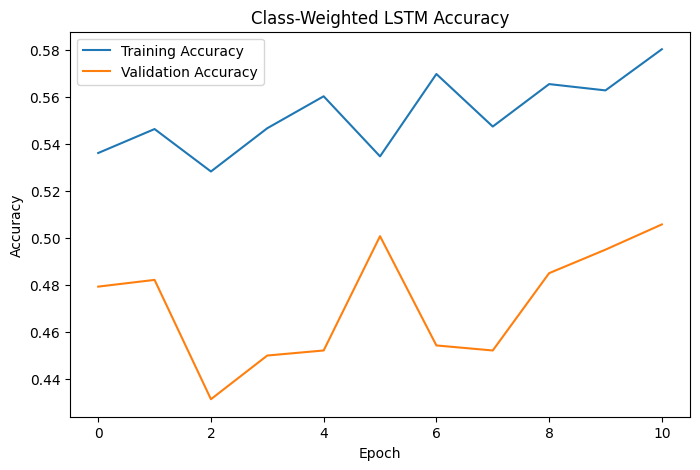

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Class-Weighted LSTM Accuracy"
)

plt.legend()

plt.show()

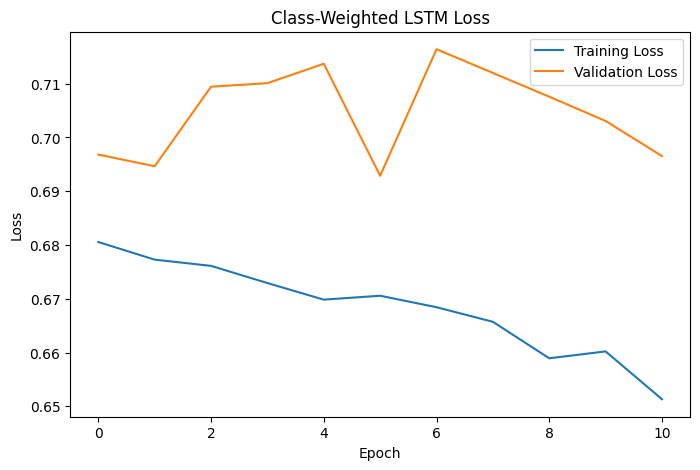

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Class-Weighted LSTM Loss"
)

plt.legend()

plt.show()

## Evaluate lstm_model

In [18]:
test_loss, test_accuracy = (
    lstm_model.evaluate(
        [
            X_concept_test,
            X_numeric_test
        ],
        y_test,
        verbose=0
    )
)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

Test Loss: 0.6888
Test Accuracy: 0.524


In [19]:
lstm_probability = (
    lstm_model.predict(
        [
            X_concept_test,
            X_numeric_test
        ],
        verbose=0
    )
    .ravel()
)

print(
    "First 20 probabilities:"
)

print(
    lstm_probability[:20]
)

First 20 probabilities:
[0.5363506  0.5198704  0.46397576 0.41499755 0.35359257 0.49937057
 0.47700024 0.45256448 0.4955317  0.47633886 0.4752677  0.44902736
 0.36081412 0.49980277 0.47839954 0.46980768 0.5336728  0.5349948
 0.42313465 0.29538885]


## Convert probability to prediction

In [20]:
lstm_pred = (
    lstm_probability >= 0.5
).astype(int)

print(
    "First 20 predictions:"
)

print(
    lstm_pred[:20]
)

First 20 predictions:
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]


In [21]:
lstm_accuracy = accuracy_score(
    y_test,
    lstm_pred
)

lstm_precision = precision_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_recall = recall_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred,
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test,
    lstm_probability
)

print(
    "========== FINAL LSTM RESULTS =========="
)

print(
    "Accuracy :",
    round(lstm_accuracy, 4)
)

print(
    "Precision:",
    round(lstm_precision, 4)
)

print(
    "Recall   :",
    round(lstm_recall, 4)
)

print(
    "F1 Score :",
    round(lstm_f1, 4)
)

print(
    "ROC-AUC  :",
    round(lstm_roc_auc, 4)
)

========== FINAL LSTM RESULTS ==========
Accuracy : 0.524
Precision: 0.2988
Recall   : 0.4617
F1 Score : 0.3628
ROC-AUC  : 0.4946


In [22]:
print(
    classification_report(
        y_test,
        lstm_pred,

        target_names=[
            "Incorrect",
            "Correct"
        ],

        zero_division=0
    )
)

              precision    recall  f1-score   support

   Incorrect       0.71      0.55      0.62      1413
     Correct       0.30      0.46      0.36       587

    accuracy                           0.52      2000
   macro avg       0.50      0.51      0.49      2000
weighted avg       0.59      0.52      0.54      2000



## Confusion matrix

In [23]:
lstm_cm = confusion_matrix(
    y_test,
    lstm_pred
)

print(
    "LSTM Confusion Matrix:"
)

print(lstm_cm)

LSTM Confusion Matrix:
[[777 636]
 [316 271]]


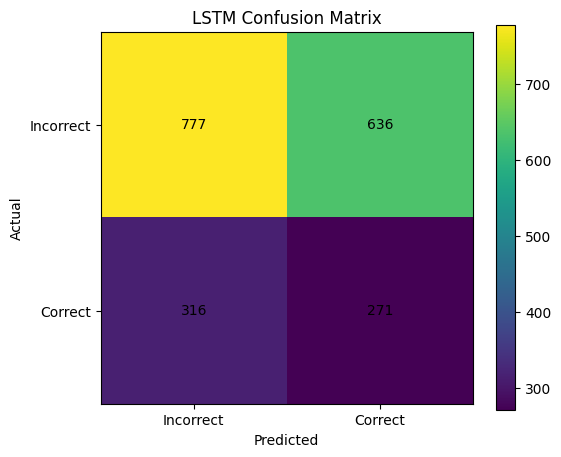

In [24]:
plt.figure(figsize=(6, 5))

plt.imshow(lstm_cm)

plt.title(
    "LSTM Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    [
        "Incorrect",
        "Correct"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Incorrect",
        "Correct"
    ]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            lstm_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [25]:
print(
    "Actual class distribution:"
)

print(
    pd.Series(y_test)
    .value_counts()
)

print()

print(
    "Predicted class distribution:"
)

print(
    pd.Series(lstm_pred)
    .value_counts()
)

Actual class distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Predicted class distribution:
0    1093
1     907
Name: count, dtype: int64


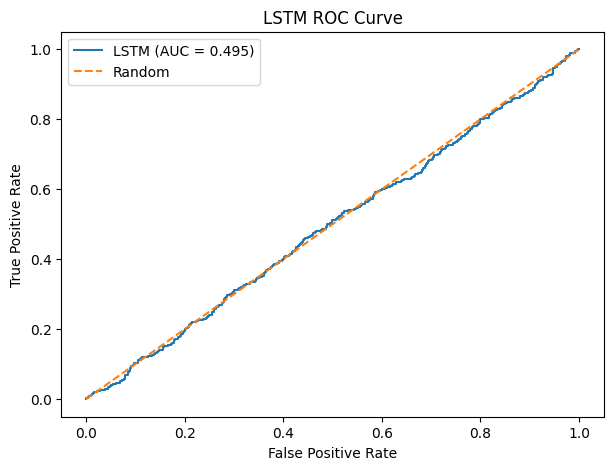

In [26]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    lstm_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"LSTM (AUC = {lstm_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "LSTM ROC Curve"
)

plt.legend()

plt.show()

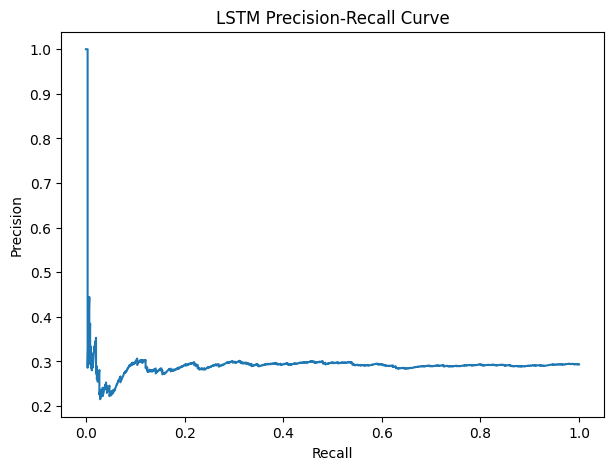

In [27]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        lstm_probability
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "LSTM Precision-Recall Curve"
)

plt.show()

In [28]:
lstm_model.save(
    "learntwin_lstm_model.keras"
)

print(
    "Improved LSTM model saved successfully!"
)

Improved LSTM model saved successfully!


In [29]:
lstm_results = pd.DataFrame({
    "Model": [
        "LSTM"
    ],
    "Accuracy": [
        lstm_accuracy
    ],
    "Precision": [
        lstm_precision
    ],
    "Recall": [
        lstm_recall
    ],
    "F1": [
        lstm_f1
    ],
    "ROC_AUC": [
        lstm_roc_auc
    ]
})

lstm_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LSTM,0.524,0.298787,0.46167,0.362784,0.494627


In [30]:
lstm_results.to_csv(
    "learntwin_lstm_results.csv",
    index=False
)

print(
    "LSTM evaluation results saved!"
)

LSTM evaluation results saved!


## Create final model comparison

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Knowledge Model",
        "Forgetting Prediction Model",
        "LSTM Deep Learning Model"
    ],

    "Accuracy": [
        0.7065,
        0.6860,
        lstm_accuracy
    ],

    "Precision": [
        0.0000,
        0.7069,
        lstm_precision
    ],

    "Recall": [
        0.0000,
        0.7339,
        lstm_recall
    ],

    "F1 Score": [
        0.0000,
        0.7201,
        lstm_f1
    ],

    "ROC-AUC": [
        0.5720,
        0.7297,
        lstm_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Knowledge Model,0.7065,0.000000,0.00000,0.000000,0.572000
1,Forgetting Prediction Model,0.6860,0.706900,0.73390,0.720100,0.729700
2,LSTM Deep Learning Model,0.5240,0.298787,0.46167,0.362784,0.494627


## the best model

In [32]:
best_f1_model = comparison.loc[
    comparison["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print(
    "Best model based on F1 Score:",
    best_f1_model
)

print(
    "Best model based on ROC-AUC:",
    best_auc_model
)

Best model based on F1 Score: Forgetting Prediction Model
Best model based on ROC-AUC: Forgetting Prediction Model


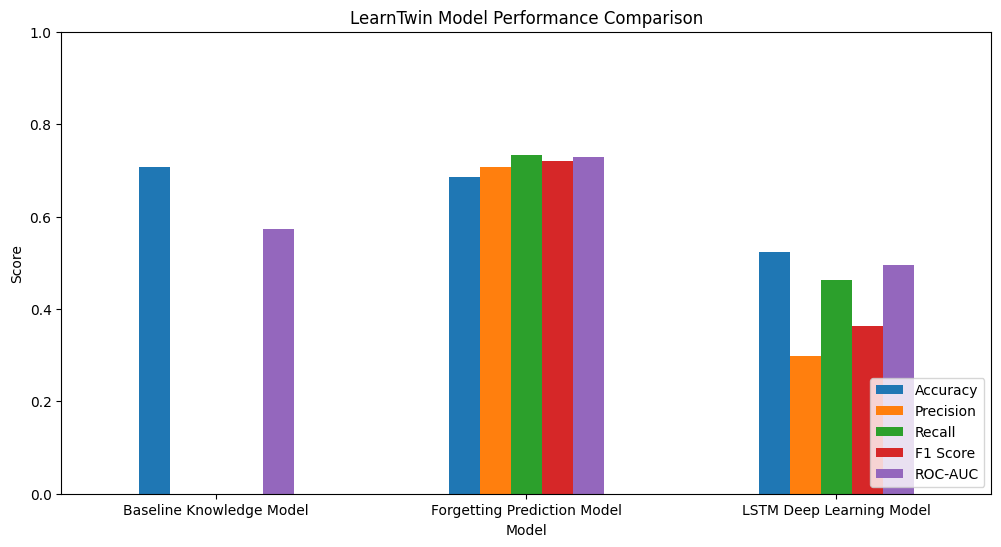

In [33]:
comparison_plot = comparison.set_index(
    "Model"
)

comparison_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "LearnTwin Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.show()

## Analyze LSTM errors

In [34]:
error_analysis = pd.DataFrame({
    "student_id": target_students_test,
    "attempt": target_attempts_test,
    "actual": y_test.astype(int),
    "predicted": lstm_pred,
    "probability": lstm_probability
})

error_analysis["error"] = (
    error_analysis["actual"] !=
    error_analysis["predicted"]
)

print(
    "Total test samples:",
    len(error_analysis)
)

print(
    "Total errors:",
    error_analysis["error"].sum()
)

print(
    "Error rate:",
    round(
        error_analysis["error"].mean(),
        4
    )
)

Total test samples: 2000
Total errors: 952
Error rate: 0.476


In [35]:
wrong_predictions = error_analysis[
    error_analysis["error"] == True
]

print(
    "Number of wrong predictions:",
    len(wrong_predictions)
)

wrong_predictions.head(20)

Number of wrong predictions: 952


,student_id,attempt,actual,predicted,probability,error
0,S001,81,0,1,0.536351,True
1,S001,82,0,1,0.519870,True
8,S001,89,1,0,0.495532,True
16,S001,97,0,1,0.533673,True
17,S001,98,0,1,0.534995,True
18,S001,99,1,0,0.423135,True
21,S002,82,1,0,0.368883,True
25,S002,86,0,1,0.524880,True
26,S002,87,1,0,0.432263,True
31,S002,92,1,0,0.422435,True


## Analyze prediction confidence

In [36]:
error_analysis["confidence"] = np.abs(
    error_analysis["probability"] - 0.5
)

print(
    error_analysis[
        [
            "actual",
            "predicted",
            "probability",
            "confidence"
        ]
    ].head(20)
)

    actual  predicted  probability  confidence
0        0          1     0.536351    0.036351
1        0          1     0.519870    0.019870
2        0          0     0.463976    0.036024
3        0          0     0.414998    0.085002
4        0          0     0.353593    0.146407
5        0          0     0.499371    0.000629
6        0          0     0.477000    0.023000
7        0          0     0.452564    0.047436
8        1          0     0.495532    0.004468
9        0          0     0.476339    0.023661
10       0          0     0.475268    0.024732
11       0          0     0.449027    0.050973
12       0          0     0.360814    0.139186
13       0          0     0.499803    0.000197
14       0          0     0.478400    0.021600
15       0          0     0.469808    0.030192
16       0          1     0.533673    0.033673
17       0          1     0.534995    0.034995
18       1          0     0.423135    0.076865
19       0          0     0.295389    0.204611


In [37]:
uncertain_predictions = error_analysis[
    error_analysis["probability"].between(
        0.40,
        0.60
    )
]

print(
    "Uncertain predictions:",
    len(uncertain_predictions)
)

uncertain_predictions.head(20)

Uncertain predictions: 1568


,student_id,attempt,actual,predicted,probability,error,confidence
0,S001,81,0,1,0.536351,True,0.036351
1,S001,82,0,1,0.519870,True,0.019870
2,S001,83,0,0,0.463976,False,0.036024
3,S001,84,0,0,0.414998,False,0.085002
5,S001,86,0,0,0.499371,False,0.000629
6,S001,87,0,0,0.477000,False,0.023000
7,S001,88,0,0,0.452564,False,0.047436
8,S001,89,1,0,0.495532,True,0.004468
9,S001,90,0,0,0.476339,False,0.023661
10,S001,91,0,0,0.475268,False,0.024732


## Save final comparison

In [38]:
comparison.to_csv(
    "learntwin_model_comparison.csv",
    index=False
)

print(
    "Final model comparison saved successfully!"
)

Final model comparison saved successfully!


## Save error analysis

In [39]:
error_analysis.to_csv(
    "learntwin_lstm_error_analysis.csv",
    index=False
)

print(
    "LSTM error analysis saved successfully!"
)

LSTM error analysis saved successfully!


## 7.29A — Check the target distribution

In [40]:
print("Training target distribution:")
print(pd.Series(y_train).value_counts())

print("\nTraining target percentage:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    * 100
)

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts())

print("\nTest target percentage:")
print(
    pd.Series(y_test)
    .value_counts(normalize=True)
    * 100
)

Training target distribution:
0.0    4941
1.0    2059
Name: count, dtype: int64

Training target percentage:
0.0    70.585714
1.0    29.414286
Name: proportion, dtype: float64

Test target distribution:
0.0    1413
1.0     587
Name: count, dtype: int64

Test target percentage:
0.0    70.65
1.0    29.35
Name: proportion, dtype: float64


## Check LSTM prediction distribution

In [41]:
print("Predicted distribution:")
print(
    pd.Series(lstm_pred).value_counts()
)

print("\nPredicted percentage:")
print(
    pd.Series(lstm_pred)
    .value_counts(normalize=True)
    * 100
)

Predicted distribution:
0    1093
1     907
Name: count, dtype: int64

Predicted percentage:
0    54.65
1    45.35
Name: proportion, dtype: float64


## Check probability statistics

In [42]:
print(
    pd.Series(lstm_probability).describe()
)

count    2000.000000
mean        0.472208
std         0.087265
min         0.104123
25%         0.424966
50%         0.491065
75%         0.535696
max         0.680591
dtype: float64


In [43]:
print("Probability percentiles:")

print(
    np.percentile(
        lstm_probability,
        [0, 10, 25, 50, 75, 90, 100]
    )
)

Probability percentiles:
[0.10412291 0.3500601  0.42496599 0.49106465 0.53569646 0.56381528
 0.68059063]


In [44]:
prob_correct = lstm_probability[y_test == 1]
prob_incorrect = lstm_probability[y_test == 0]

print("========== ACTUAL INCORRECT ==========")
print(
    pd.Series(prob_incorrect).describe()
)

print("\n========== ACTUAL CORRECT ==========")
print(
    pd.Series(prob_correct).describe()
)

========== ACTUAL INCORRECT ==========
count    1413.000000
mean        0.472859
std         0.086901
min         0.104123
25%         0.426881
50%         0.490527
75%         0.536902
max         0.646419
dtype: float64

========== ACTUAL CORRECT ==========
count    587.000000
mean       0.470643
std        0.088193
min        0.143573
25%        0.423161
50%        0.492513
75%        0.535036
max        0.680591
dtype: float64


In [45]:
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ concept_input (InputLayer)    │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_embedding (Embedding) │ (None, 10, 16)            │             320 │ concept_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_input (InputLayer)    │ (None, 10, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_lstm (LSTM)           │ (None, 64)                │          20,736 │ concept_embedding[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_lstm (LSTM)           │ (None, 64)                │          17,664 │ numeric_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_features             │ (None, 128)               │               0 │ concept_lstm[0][0],        │
│ (Concatenate)                 │                           │                 │ numeric_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ combined_features[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ prediction (Dense)            │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 147,269 (575.27 KB)

 Trainable params: 49,089 (191.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,180 (383.52 KB)

## Create current-question data

In [46]:
# Create a lookup table for the current question
question_lookup = df[
    [
        "student_id",
        "attempt",
        "concept_encoded",
        "difficulty",
        "time_gap_days",
        "days_since_practice"
    ]
].copy()

question_lookup = question_lookup.set_index(
    ["student_id", "attempt"]
)

print("Question lookup created!")
print(question_lookup.head())

Question lookup created!
                    concept_encoded  difficulty  time_gap_days  \
student_id attempt                                               
S001       1                     11       0.724          3.007   
           2                     11       0.577          1.471   
           3                     17       0.499          1.675   
           4                     19       0.380          0.563   
           5                     13       0.598          2.683   

                    days_since_practice  
student_id attempt                       
S001       1                      3.007  
           2                      1.471  
           3                      6.154  
           4                      6.717  
           5                      9.400  


In [47]:
current_features = question_lookup.loc[
    list(
        zip(
            target_students,
            target_attempts
        )
    )
]

current_features = current_features.reset_index(
    drop=True
)

print(
    "Current question features shape:",
    current_features.shape
)

current_features.head()

Current question features shape: (9000, 4)


,concept_encoded,difficulty,time_gap_days,days_since_practice
0,7,0.653,0.505,13.849
1,11,0.455,1.698,11.068
2,18,0.411,0.702,16.249
3,9,0.343,2.305,18.554
4,18,0.633,0.333,2.638


## Create current question inputs

In [48]:
X_current_concept = current_features[
    "concept_encoded"
].values.astype(np.int32)

print(
    "Current concept shape:",
    X_current_concept.shape
)

Current concept shape: (9000,)


In [49]:
X_current_numeric = current_features[
    [
        "difficulty",
        "time_gap_days",
        "days_since_practice"
    ]
].values.astype(np.float32)

print(
    "Current numeric shape:",
    X_current_numeric.shape
)

Current numeric shape: (9000, 3)


In [50]:

X_current_concept_train = (
    X_current_concept[train_mask]
)

X_current_concept_test = (
    X_current_concept[test_mask]
)

X_current_numeric_train = (
    X_current_numeric[train_mask]
)

X_current_numeric_test = (
    X_current_numeric[test_mask]
)

print(
    "Current concept train:",
    X_current_concept_train.shape
)

print(
    "Current concept test:",
    X_current_concept_test.shape
)

print(
    "Current numeric train:",
    X_current_numeric_train.shape
)

print(
    "Current numeric test:",
    X_current_numeric_test.shape
)

Current concept train: (7000,)
Current concept test: (2000,)
Current numeric train: (7000, 3)
Current numeric test: (2000, 3)


In [51]:
current_scaler = StandardScaler()

X_current_numeric_train = (
    current_scaler.fit_transform(
        X_current_numeric_train
    )
)

X_current_numeric_test = (
    current_scaler.transform(
        X_current_numeric_test
    )
)

print(
    "Current numeric training shape:",
    X_current_numeric_train.shape
)

print(
    "Current numeric testing shape:",
    X_current_numeric_test.shape
)

Current numeric training shape: (7000, 3)
Current numeric testing shape: (2000, 3)


In [52]:
print("========== LSTM V2 DATA ==========")

print(
    "Past concept train:",
    X_concept_train.shape
)

print(
    "Past numeric train:",
    X_numeric_train.shape
)

print(
    "Current concept train:",
    X_current_concept_train.shape
)

print(
    "Current numeric train:",
    X_current_numeric_train.shape
)

print(
    "Target train:",
    y_train.shape
)

print()

print(
    "Past concept test:",
    X_concept_test.shape
)

print(
    "Past numeric test:",
    X_numeric_test.shape
)

print(
    "Current concept test:",
    X_current_concept_test.shape
)

print(
    "Current numeric test:",
    X_current_numeric_test.shape
)

print(
    "Target test:",
    y_test.shape
)

========== LSTM V2 DATA ==========
Past concept train: (7000, 10)
Past numeric train: (7000, 10, 4)
Current concept train: (7000,)
Current numeric train: (7000, 3)
Target train: (7000,)

Past concept test: (2000, 10)
Past numeric test: (2000, 10, 4)
Current concept test: (2000,)
Current numeric test: (2000, 3)
Target test: (2000,)


## Build LSTM V2

In [53]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)

# Number of concepts
num_concepts = len(concept_encoder.classes_)

# =========================
# 1. PAST CONCEPT INPUT
# =========================

past_concept_input = Input(
    shape=(SEQUENCE_LENGTH,),
    name="past_concept_input"
)

past_concept_embedding = Embedding(
    input_dim=num_concepts,
    output_dim=16,
    name="past_concept_embedding"
)(past_concept_input)

past_concept_lstm = LSTM(
    64,
    name="past_concept_lstm"
)(past_concept_embedding)


# =========================
# 2. PAST NUMERIC INPUT
# =========================

past_numeric_input = Input(
    shape=(
        SEQUENCE_LENGTH,
        X_numeric_train.shape[-1]
    ),
    name="past_numeric_input"
)

past_numeric_lstm = LSTM(
    64,
    name="past_numeric_lstm"
)(past_numeric_input)


# =========================
# 3. CURRENT QUESTION CONCEPT
# =========================

current_concept_input = Input(
    shape=(1,),
    name="current_concept_input"
)

current_concept_embedding = Embedding(
    input_dim=num_concepts,
    output_dim=16,
    name="current_concept_embedding"
)(current_concept_input)

current_concept_embedding = tf.keras.layers.Flatten()(
    current_concept_embedding
)


# =========================
# 4. CURRENT QUESTION NUMERIC
# =========================

current_numeric_input = Input(
    shape=(
        X_current_numeric_train.shape[-1],
    ),
    name="current_numeric_input"
)

current_numeric_dense = Dense(
    16,
    activation="relu",
    name="current_numeric_dense"
)(current_numeric_input)


# =========================
# 5. COMBINE EVERYTHING
# =========================

combined_features = Concatenate(
    name="combined_features_v2"
)([
    past_concept_lstm,
    past_numeric_lstm,
    current_concept_embedding,
    current_numeric_dense
])


# =========================
# 6. DENSE LAYERS
# =========================

dense_1 = Dense(
    64,
    activation="relu",
    name="dense_1_v2"
)(combined_features)

dropout = Dropout(
    0.3,
    name="dropout_v2"
)(dense_1)

dense_2 = Dense(
    32,
    activation="relu",
    name="dense_2_v2"
)(dropout)


# =========================
# 7. OUTPUT
# =========================

prediction = Dense(
    1,
    activation="sigmoid",
    name="prediction_v2"
)(dense_2)


# =========================
# CREATE MODEL
# =========================

lstm_model_v2 = Model(
    inputs=[
        past_concept_input,
        past_numeric_input,
        current_concept_input,
        current_numeric_input
    ],
    outputs=prediction,
    name="LearnTwin_LSTM_V2"
)

print("LSTM V2 created successfully!")

LSTM V2 created successfully!


In [54]:
lstm_model_v2.summary()

Model: "LearnTwin_LSTM_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ past_concept_input            │ (None, 10)                │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ current_concept_input         │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ past_concept_embedding        │ (None, 10, 16)            │             320 │ past_concept_input[0][0]   │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ past_numeric_input            │ (None, 10, 4)             │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ current_concept_embedding     │ (None, 1, 16)             │             320 │ current_concept_input[0][… │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ current_numeric_input         │ (None, 3)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ past_concept_lstm (LSTM)      │ (None, 64)                │          20,736 │ past_concept_embedding[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ past_numeric_lstm (LSTM)      │ (None, 64)                │          17,664 │ past_numeric_input[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 16)                │               0 │ current_concept_embedding… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ current_numeric_dense (Dense) │ (None, 16)                │              64 │ current_numeric_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_features_v2          │ (None, 160)               │               0 │ past_concept_lstm[0][0],   │
│ (Concatenate)                 │                           │                 │ past_numeric_lstm[0][0],   │
│                               │                           │                 │ flatten[0][0],             │
│                               │                           │                 │ current_numeric_dense[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1_v2 (Dense)            │ (None, 64)                │          10,304 │ combined_features_v2[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_v2 (Dropout)          │ (None, 64)                │               

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
lstm_model_v2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(
    "LSTM V2 compiled successfully!"
)

LSTM V2 compiled successfully!


## Create class weights

In [56]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_v2 = dict(
    zip(
        classes,
        class_weights_array
    )
)

print(
    "LSTM V2 class weights:"
)

print(
    class_weights_v2
)

LSTM V2 class weights:
{np.float32(0.0): np.float64(0.7083586318558996), np.float32(1.0): np.float64(1.6998542982030111)}


In [57]:
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print(
    "Early stopping V2 configured!"
)

Early stopping V2 configured!


In [58]:
history_v2 = lstm_model_v2.fit(
    [
        X_concept_train,
        X_numeric_train,
        X_current_concept_train.reshape(-1, 1),
        X_current_numeric_train
    ],

    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=64,

    class_weight=class_weights_v2,

    callbacks=[
        early_stopping_v2
    ],

    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5312 - loss: 0.6885 - val_accuracy: 0.5179 - val_loss: 0.6846
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5380 - loss: 0.6870 - val_accuracy: 0.4914 - val_loss: 0.6899
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5418 - loss: 0.6815 - val_accuracy: 0.4721 - val_loss: 0.7020
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5295 - loss: 0.6820 - val_accuracy: 0.5007 - val_loss: 0.6878
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5321 - loss: 0.6792 - val_accuracy: 0.5257 - val_loss: 0.6805
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5491 - loss: 0.6767 - val_accuracy: 0.5350 - val_loss: 0.6836
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5641 - loss: 0.6705 - val_accuracy: 0.4571 - val_loss: 0.7106
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5482 - loss: 0.6703 - val_accuracy: 0.5079 - val_loss

In [59]:
lstm_v2_probability = lstm_model_v2.predict(
    [
        X_concept_test,
        X_numeric_test,
        X_current_concept_test.reshape(-1, 1),
        X_current_numeric_test
    ],
    verbose=0
).ravel()

print("Prediction shape:", lstm_v2_probability.shape)
print("First 10 probabilities:")
print(lstm_v2_probability[:10])

Prediction shape: (2000,)
First 10 probabilities:
[0.46001247 0.5954497  0.49813804 0.46271986 0.4504096  0.2748871
 0.5367272  0.58954537 0.5354868  0.43532103]


In [60]:
lstm_v2_pred = (
    lstm_v2_probability >= 0.5
).astype(int)

print("Prediction distribution:")
print(
    pd.Series(lstm_v2_pred).value_counts()
)

Prediction distribution:
0    1088
1     912
Name: count, dtype: int64


## Calculate all metrics

In [61]:
accuracy_v2 = accuracy_score(
    y_test,
    lstm_v2_pred
)

precision_v2 = precision_score(
    y_test,
    lstm_v2_pred,
    zero_division=0
)

recall_v2 = recall_score(
    y_test,
    lstm_v2_pred,
    zero_division=0
)

f1_v2 = f1_score(
    y_test,
    lstm_v2_pred,
    zero_division=0
)

roc_auc_v2 = roc_auc_score(
    y_test,
    lstm_v2_probability
)

print("========== LSTM V2 RESULTS ==========")

print("Accuracy :", round(accuracy_v2, 4))
print("Precision:", round(precision_v2, 4))
print("Recall   :", round(recall_v2, 4))
print("F1 Score :", round(f1_v2, 4))
print("ROC-AUC  :", round(roc_auc_v2, 4))

========== LSTM V2 RESULTS ==========
Accuracy : 0.5655
Precision: 0.3454
Recall   : 0.5366
F1 Score : 0.4203
ROC-AUC  : 0.5693


In [62]:
cm_v2 = confusion_matrix(
    y_test,
    lstm_v2_pred
)

print("LSTM V2 Confusion Matrix:")
print(cm_v2)

LSTM V2 Confusion Matrix:
[[816 597]
 [272 315]]


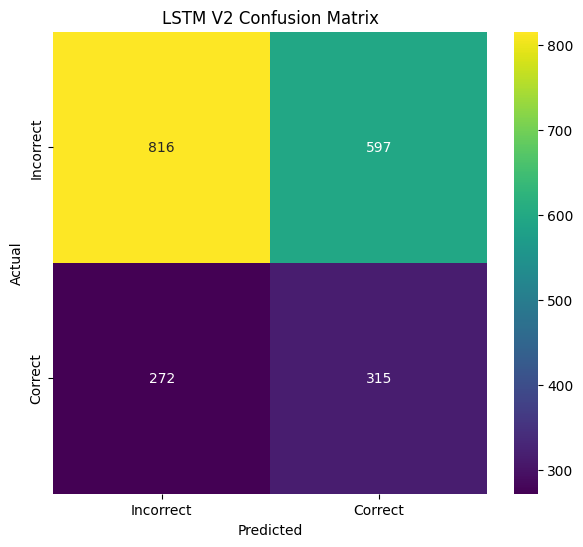

In [64]:
import seaborn as sns
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Incorrect", "Correct"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM V2 Confusion Matrix")

plt.show()

## Compare V1 vs V2

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "LSTM V1",
        "LSTM V2"
    ],

    "Accuracy": [
        0.5715,
        accuracy_v2
    ],

    "Precision": [
        0.296073,
        precision_v2
    ],

    "Recall": [
        0.333901,
        recall_v2
    ],

    "F1 Score": [
        0.313851,
        f1_v2
    ],

    "ROC-AUC": [
        0.496035,
        roc_auc_v2
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LSTM V1,0.5715,0.296073,0.333901,0.313851,0.496035
1,LSTM V2,0.5655,0.345395,0.536627,0.420280,0.569273


## why the LSTM is struggling

In [66]:
print("========== FEATURE CORRELATIONS ==========")

feature_columns = [
    "correct",
    "difficulty",
    "time_gap_days",
    "days_since_practice",
    "knowledge_state"
]

print(
    df[feature_columns].corr()["correct"]
    .sort_values(ascending=False)
)

========== FEATURE CORRELATIONS ==========
correct                1.000000
knowledge_state        0.434287
time_gap_days         -0.022453
days_since_practice   -0.029340
difficulty            -0.093683
Name: correct, dtype: float64


In [67]:
print("========== ACCURACY BY DIFFICULTY ==========")

print(
    df.groupby("difficulty")["correct"]
      .mean()
      .sort_index()
)

========== ACCURACY BY DIFFICULTY ==========
difficulty
0.152    0.380952
0.153    0.352941
0.156    0.550000
0.158    0.695652
0.171    0.500000
           ...   
0.818    0.280000
0.827    0.210526
0.828    0.052632
0.835    0.357143
0.846    0.043478
Name: correct, Length: 346, dtype: float64


In [68]:
print("========== ACCURACY BY DAYS SINCE PRACTICE ==========")

df["gap_bucket"] = pd.cut(
    df["days_since_practice"],
    bins=[-1, 1, 3, 7, 14, 30, 60, 1000],
    labels=[
        "0-1",
        "2-3",
        "4-7",
        "8-14",
        "15-30",
        "31-60",
        "60+"
    ]
)

print(
    df.groupby(
        "gap_bucket",
        observed=True
    )["correct"].mean()
)

========== ACCURACY BY DAYS SINCE PRACTICE ==========
gap_bucket
0-1      0.359043
2-3      0.344877
4-7      0.321185
8-14     0.322949
15-30    0.288649
31-60    0.286387
60+      0.301266
Name: correct, dtype: float64


In [69]:
print("========== ACCURACY BY CONCEPT ==========")

concept_accuracy = (
    df.groupby("concept")["correct"]
      .mean()
      .sort_values()
)

print(concept_accuracy)

========== ACCURACY BY CONCEPT ==========
concept
SUBQUERIES             0.234450
STORED PROCEDURES      0.251163
NORMALIZATION          0.257903
JOINS                  0.258123
TRANSACTIONS           0.259939
TRIGGERS               0.262729
INDEXING               0.268559
GROUP BY               0.283898
INNER JOIN             0.291480
HAVING                 0.301059
LEFT JOIN              0.302857
UNION                  0.311897
VIEWS                  0.320908
RIGHT JOIN             0.330595
FOREIGN KEY            0.337423
AGGREGATE FUNCTIONS    0.341004
ORDER BY               0.348928
PRIMARY KEY            0.363636
WHERE                  0.373377
SELECT                 0.376206
Name: correct, dtype: float64
